In [1]:
# EXPERIMENT 3
# Image Noise Removal using Mean and Median Filters
# Effect of different Kernel Sizes and Strides

import numpy as np
import cv2
import matplotlib.pyplot as plt

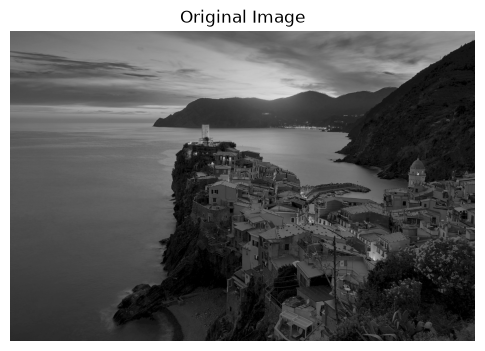

In [2]:
# 1. READ AND DISPLAY ORIGINAL IMAGE

img = cv2.imread(
    "/Users/vanshilpatel/Desktop/pdeu/cv pdeu/exp3/Image.png",
    cv2.IMREAD_GRAYSCALE
)

plt.figure(figsize=(6, 5))
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

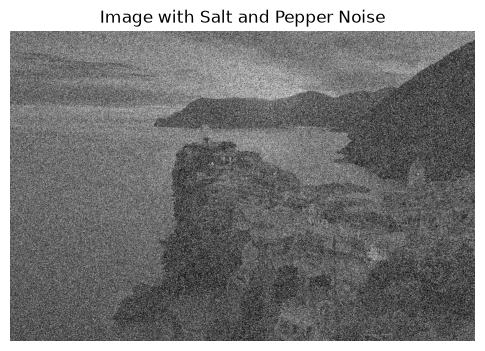

In [3]:
# 2. GENERATE SALT AND PEPPER NOISE

def create_noisy_image(img, noise_level=0.5):

    result = img.copy()

    random_values = np.random.random(img.shape)

    black_limit = noise_level / 2
    white_limit = 1 - black_limit

    result[random_values < black_limit] = 0
    result[random_values > white_limit] = 255

    return result


noisy_img = create_noisy_image(img, noise_level=0.5)


plt.figure(figsize=(6, 5))
plt.imshow(noisy_img, cmap="gray")
plt.title("Image with Salt and Pepper Noise")
plt.axis("off")
plt.show()

In [4]:

# 3. MEDIAN FILTER
def apply_median(img, window_size=3, step_size=1):

    height, width = img.shape

    border = window_size // 2

    extended_img = np.pad(
        img,
        border,
        mode="reflect"
    )

    result_height = (
        height - window_size + 2 * border
    ) // step_size + 1

    result_width = (
        width - window_size + 2 * border
    ) // step_size + 1

    filtered = np.zeros(
        (result_height, result_width),
        dtype=img.dtype
    )

    for row in range(result_height):

        for col in range(result_width):

            start_row = row * step_size
            start_col = col * step_size

            region = extended_img[
                start_row:start_row + window_size,
                start_col:start_col + window_size
            ]

            filtered[row, col] = np.median(region)

    return filtered


In [ ]:

# 4. MEAN FILTER

def apply_mean(img, window_size=3, step_size=1):

    height, width = img.shape

    border = window_size // 2

    extended_img = np.pad(
        img,
        border,
        mode="reflect"
    )

    result_height = (
        height - window_size + 2 * border
    ) // step_size + 1

    result_width = (
        width - window_size + 2 * border
    ) // step_size + 1

    filtered = np.zeros(
        (result_height, result_width),
        dtype=img.dtype
    )

    for row in range(result_height):

        for col in range(result_width):

            start_row = row * step_size
            start_col = col * step_size

            region = extended_img[
                start_row:start_row + window_size,
                start_col:start_col + window_size
            ]

            filtered[row, col] = np.mean(region)

    return filtered



In [ ]:
# 5. APPLY BOTH FILTERS

mean_result = apply_mean(
    noisy_img,
    window_size=3,
    step_size=1
)

median_result = apply_median(
    noisy_img,
    window_size=3,
    step_size=1
)


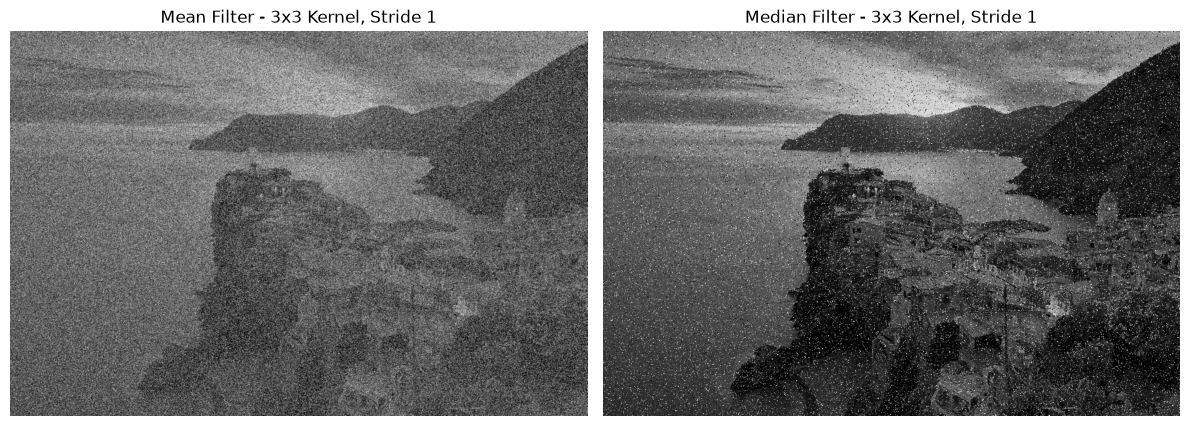

In [ ]:
# 6. DISPLAY MEAN AND MEDIAN RESULTS

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(mean_result, cmap="gray")
plt.title("Mean Filter - 3x3 Kernel, Stride 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(median_result, cmap="gray")
plt.title("Median Filter - 3x3 Kernel, Stride 1")
plt.axis("off")

plt.tight_layout()
plt.show()


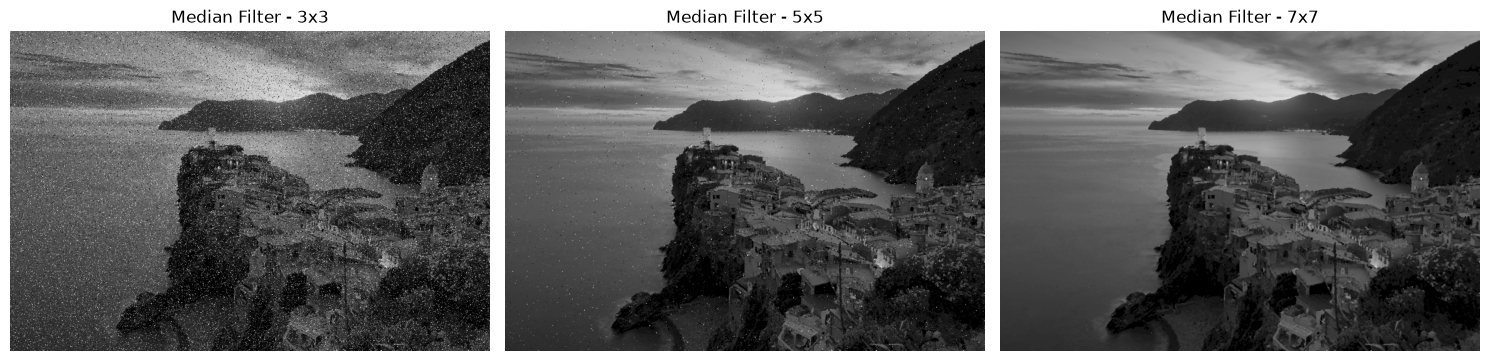

In [8]:
# 7. EFFECT OF DIFFERENT KERNEL SIZES

median_3 = apply_median(
    noisy_img,
    window_size=3,
    step_size=1
)

median_5 = apply_median(
    noisy_img,
    window_size=5,
    step_size=1
)

median_7 = apply_median(
    noisy_img,
    window_size=7,
    step_size=1
)


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(median_3, cmap="gray")
plt.title("Median Filter - 3x3")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(median_5, cmap="gray")
plt.title("Median Filter - 5x5")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(median_7, cmap="gray")
plt.title("Median Filter - 7x7")
plt.axis("off")

plt.tight_layout()
plt.show()



In [9]:
# 8. EFFECT OF DIFFERENT STRIDE VALUES

stride_one = apply_median(
    noisy_img,
    window_size=3,
    step_size=1
)

stride_two = apply_median(
    noisy_img,
    window_size=3,
    step_size=2
)

stride_three = apply_median(
    noisy_img,
    window_size=3,
    step_size=3
)


# Display output dimensions
print("Output Shape with Stride 1:", stride_one.shape)
print("Output Shape with Stride 2:", stride_two.shape)
print("Output Shape with Stride 3:", stride_three.shape)

Output Shape with Stride 1: (1600, 2400)
Output Shape with Stride 2: (800, 1200)
Output Shape with Stride 3: (534, 800)


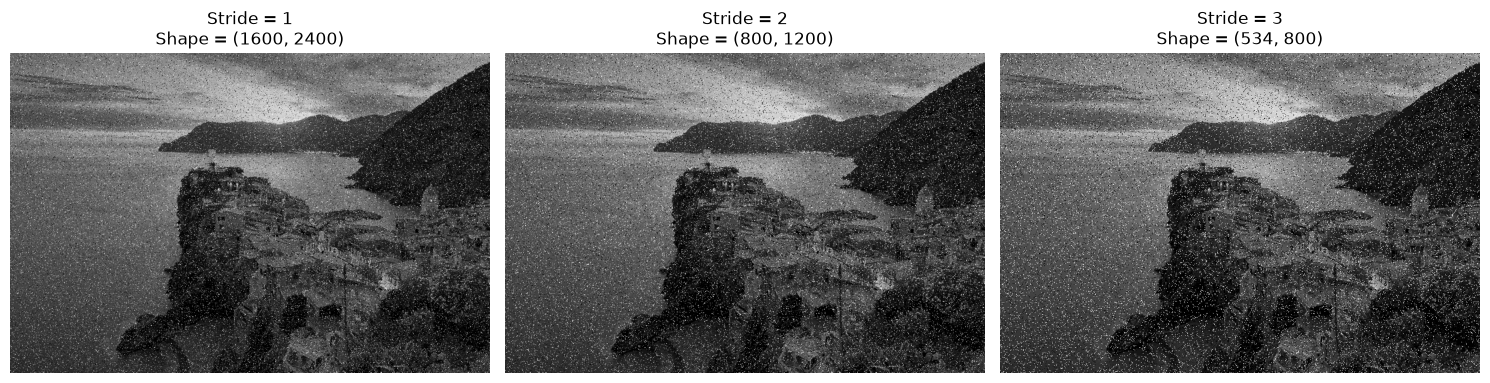

In [10]:
# 9. VISUALIZE STRIDE EFFECT

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(stride_one, cmap="gray")
plt.title(f"Stride = 1\nShape = {stride_one.shape}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(stride_two, cmap="gray")
plt.title(f"Stride = 2\nShape = {stride_two.shape}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(stride_three, cmap="gray")
plt.title(f"Stride = 3\nShape = {stride_three.shape}")
plt.axis("off")

plt.tight_layout()
plt.show()